In [ ]:
# Multiclass Classification
# -> 3 or more classes
# -> NaiveBayes, KNN, Decision Tree, Random Forest(Base is DT)

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [7]:
# load the datset
data_df = pd.read_csv('online_gaming_behavior_dataset.csv')
data_df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [9]:
# explore dataset 
data_df.shape

(40034, 13)

In [11]:
# check for missing values
data_df.isnull().sum()

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [13]:
# distribution of target variable
data_df['EngagementLevel'].value_counts()

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64

In [17]:
# Convert categorical columns into numeric columns
# use LabelEncoder

X = data_df.drop(columns=['PlayerID','EngagementLevel'])
y = data_df['EngagementLevel']

categorical_cols = ['Gender','Location','GameGenre','GameDifficulty']
label_encoders = {}
for col in categorical_cols :
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [19]:
# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [21]:
# Apply Standard Scaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [31]:
# Apply GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train_sc, y_train)

# predict testing set
y_pred_test = nb_model.predict(X_test_sc)
y_pred_test_prob = nb_model.predict_proba(X_test_sc)

# Determine class order
class_order = nb_model.classes_
print("Class Order : ", nb_model.classes_)

# display results
results_nb = pd.DataFrame({
    'Actual label' : y_test,
    'Predicted Label' : y_pred_test   
})

# 3 probs - probhigh, problow, probmed
# Add probabilities
for i, class_name in enumerate(class_order) :
    results_nb[f'Predicted Probability {class_name}'] = np.round(y_pred_test_prob[:,i],2)

results_nb.head(10)

Class Order :  ['High' 'Low' 'Medium']


,Actual label,Predicted Label,Predicted Probability High,Predicted Probability Low,Predicted Probability Medium
34667,Medium,Medium,0.22,0.07,0.71
22227,Medium,Medium,0.19,0.17,0.64
24899,Medium,Medium,0.01,0.34,0.66
35415,Medium,Medium,0.21,0.16,0.63
21440,Medium,Medium,0.34,0.13,0.52
32877,High,High,0.62,0.03,0.35
34287,Low,Low,0.00,0.59,0.41
7568,High,Medium,0.41,0.03,0.56
23191,High,High,0.74,0.02,0.23
1483,Low,Low,0.00,0.61,0.39


In [35]:
# Evaluate nb - accuracy, cf, cr
training_accuracy = accuracy_score(y_train, nb_model.predict(X_train_sc))
testing_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Training Accuracy : {training_accuracy}")
print(f"Testing Accuracy : {testing_accuracy}")
print()

conf_matrix = confusion_matrix(y_test, y_pred_test, labels=class_order)
print(conf_matrix)
print()
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_order, columns=class_order)
print(conf_matrix_df)
print()

class_report = classification_report(y_test, y_pred_test)
print(class_report)


Training Accuracy : 0.8454483816864719
Testing Accuracy : 0.8384813920572808

[[2422   88  622]
 [  81 2109  879]
 [ 100  170 5540]]

        High   Low  Medium
High    2422    88     622
Low       81  2109     879
Medium   100   170    5540

              precision    recall  f1-score   support

        High       0.93      0.77      0.84      3132
         Low       0.89      0.69      0.78      3069
      Medium       0.79      0.95      0.86      5810

    accuracy                           0.84     12011
   macro avg       0.87      0.80      0.83     12011
weighted avg       0.85      0.84      0.84     12011



In [37]:
# KNN , k=3
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_sc, y_train)

# predict testing set
y_pred_test = knn_model.predict(X_test_sc)
y_pred_test_prob = knn_model.predict_proba(X_test_sc)

# Determine class order
class_order = knn_model.classes_
print("Class Order : ", knn_model.classes_)

# display results
results_knn = pd.DataFrame({
    'Actual label' : y_test,
    'Predicted Label' : y_pred_test   
})

# 3 probs - probhigh, problow, probmed
# Add probabilities
for i, class_name in enumerate(class_order) :
    results_knn[f'Predicted Probability {class_name}'] = np.round(y_pred_test_prob[:,i],2)

results_knn.head(10)

# Evaluate nb - accuracy, cf, cr
training_accuracy = accuracy_score(y_train, knn_model.predict(X_train_sc))
testing_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Training Accuracy : {training_accuracy}")
print(f"Testing Accuracy : {testing_accuracy}")
print()

conf_matrix = confusion_matrix(y_test, y_pred_test, labels=class_order)
print(conf_matrix)
print()
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_order, columns=class_order)
print(conf_matrix_df)
print()

class_report = classification_report(y_test, y_pred_test)
print(class_report)


Class Order :  ['High' 'Low' 'Medium']
Training Accuracy : 0.8663597758983692
Testing Accuracy : 0.7335775539089169

[[2371  105  656]
 [ 188 1839 1042]
 [ 648  561 4601]]

        High   Low  Medium
High    2371   105     656
Low      188  1839    1042
Medium   648   561    4601

              precision    recall  f1-score   support

        High       0.74      0.76      0.75      3132
         Low       0.73      0.60      0.66      3069
      Medium       0.73      0.79      0.76      5810

    accuracy                           0.73     12011
   macro avg       0.73      0.72      0.72     12011
weighted avg       0.73      0.73      0.73     12011



Class Order :  ['High' 'Low' 'Medium']
      Actual label Predicted Label  Predicted Probability High  \
34667       Medium          Medium                         0.0   
22227       Medium          Medium                         0.0   
24899       Medium             Low                         0.0   
35415       Medium          Medium                         0.0   
21440       Medium          Medium                         0.0   
32877         High            High                         1.0   
34287          Low          Medium                         0.0   
7568          High            High                         1.0   
23191         High            High                         1.0   
1483           Low            High                         1.0   

       Predicted Probability Low  Predicted Probability Medium  
34667                        0.0                           1.0  
22227                        0.0                           1.0  
24899                        1.0       

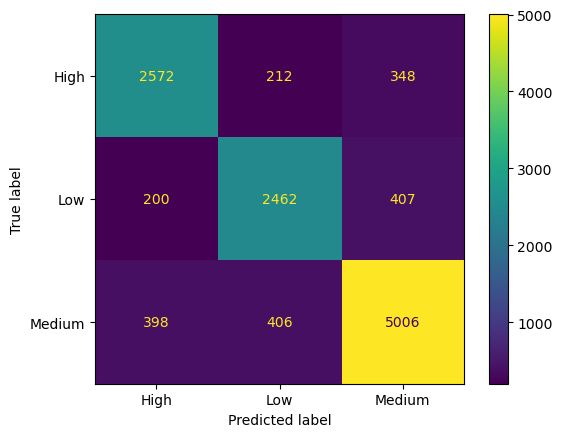

              precision    recall  f1-score   support

        High       0.81      0.82      0.82      3132
         Low       0.80      0.80      0.80      3069
      Medium       0.87      0.86      0.87      5810

    accuracy                           0.84     12011
   macro avg       0.83      0.83      0.83     12011
weighted avg       0.84      0.84      0.84     12011



In [45]:
# Decision Tree - we are getting overfitting problem
dt_model = DecisionTreeClassifier(random_state=42)
from sklearn.metrics import ConfusionMatrixDisplay
dt_model.fit(X_train_sc, y_train)

# predict testing set
y_pred_test = dt_model.predict(X_test_sc)
y_pred_test_prob = dt_model.predict_proba(X_test_sc)

# Determine class order
class_order = knn_model.classes_
print("Class Order : ", dt_model.classes_)

# display results
results_dt = pd.DataFrame({
    'Actual label' : y_test,
    'Predicted Label' : y_pred_test   
})

# 3 probs - probhigh, problow, probmed
# Add probabilities
for i, class_name in enumerate(class_order) :
    results_dt[f'Predicted Probability {class_name}'] = np.round(y_pred_test_prob[:,i],2)

print(results_dt.head(10))

# Evaluate nb - accuracy, cf, cr
training_accuracy = accuracy_score(y_train, dt_model.predict(X_train_sc))
testing_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Training Accuracy : {training_accuracy}")
print(f"Testing Accuracy : {testing_accuracy}")
print()

conf_matrix = confusion_matrix(y_test, y_pred_test, labels=class_order)
print(conf_matrix)
print()
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_order, columns=class_order)
print(conf_matrix_df)
print()
cm_display =  ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = class_order)
cm_display.plot()
plt.show()

class_report = classification_report(y_test, y_pred_test)
print(class_report)

In [ ]:
# DT - overfitting
# address this limitation - Random Forest RF
# -> ensemble learning algorithm
# -> takes another alogorithm as its base
# -> DT as the base algorithm
# Dt - tree, combine multiple trees - Random Forest
# -> RF builds multiple DTs and combines their predictions to improve performance and reduce overfitting

Class Order :  ['High' 'Low' 'Medium']
      Actual label Predicted Label  Predicted Probability High  \
34667       Medium          Medium                        0.06   
22227       Medium          Medium                        0.08   
24899       Medium             Low                        0.04   
35415       Medium          Medium                        0.09   
21440       Medium          Medium                        0.23   
32877         High            High                        0.89   
34287          Low             Low                        0.04   
7568          High          Medium                        0.40   
23191         High            High                        0.89   
1483           Low             Low                        0.04   

       Predicted Probability Low  Predicted Probability Medium  
34667                       0.05                          0.89  
22227                       0.07                          0.85  
24899                       0.79       

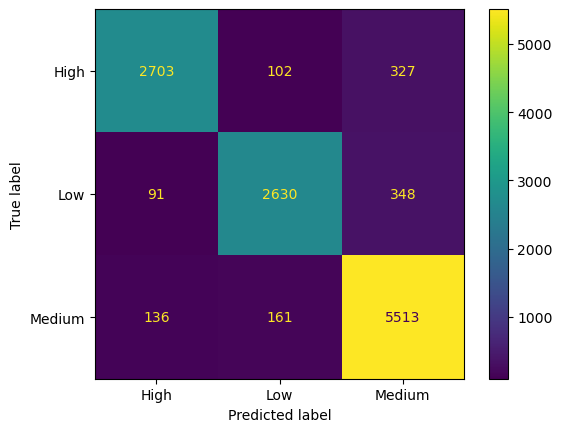

In [64]:
# Random Forest Classifier
rf_model = RandomForestClassifier(max_depth = 13, random_state=42)
rf_model.fit(X_train_sc, y_train)

# predict testing set
y_pred_test = rf_model.predict(X_test_sc)
y_pred_test_prob = rf_model.predict_proba(X_test_sc)

# Determine class order
class_order = rf_model.classes_
print("Class Order : ", rf_model.classes_)

# display results
results_rf = pd.DataFrame({
    'Actual label' : y_test,
    'Predicted Label' : y_pred_test   
})

# 3 probs - probhigh, problow, probmed
# Add probabilities
for i, class_name in enumerate(class_order) :
    results_rf[f'Predicted Probability {class_name}'] = np.round(y_pred_test_prob[:,i],2)

print(results_rf.head(10))

# Evaluate nb - accuracy, cf, cr
training_accuracy = accuracy_score(y_train, rf_model.predict(X_train_sc))
testing_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Training Accuracy : {training_accuracy}")
print(f"Testing Accuracy : {testing_accuracy}")
print()

conf_matrix = confusion_matrix(y_test, y_pred_test, labels=class_order)
print(conf_matrix)
print()
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_order, columns=class_order)
print(conf_matrix_df)
print()
cm_display =  ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = class_order)
cm_display.plot()
plt.show()